<a href="https://colab.research.google.com/github/nightshadeX16/My-Colab-ML-Projects/blob/main/Credit_Card_Fraud_Detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Import necessary libraries
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, RobustScaler
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# Suppress warnings for cleaner output
import warnings
warnings.filterwarnings('ignore')

# --- Phase 1: Data Loading ---
# The dataset 'creditcard.csv' must be downloaded from Kaggle and placed in the same directory as this script.
# Download link: https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud

try:
    df = pd.read_csv('creditcard.csv')
    print("Dataset loaded successfully!")
except FileNotFoundError:
    print("Error: 'creditcard.csv' not found. Please download the dataset from Kaggle and place it in the same directory.")
    exit()


Dataset loaded successfully!


In [ ]:
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0



--- Enhanced Exploratory Data Analysis & Preprocessing ---
Checking for missing values:
Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64
--------------------------------------------------
No missing values found in the dataset.
--------------------------------------------------


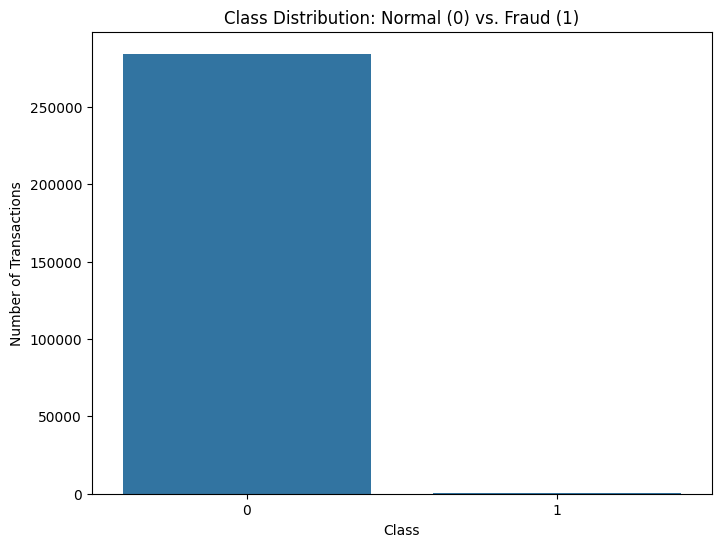

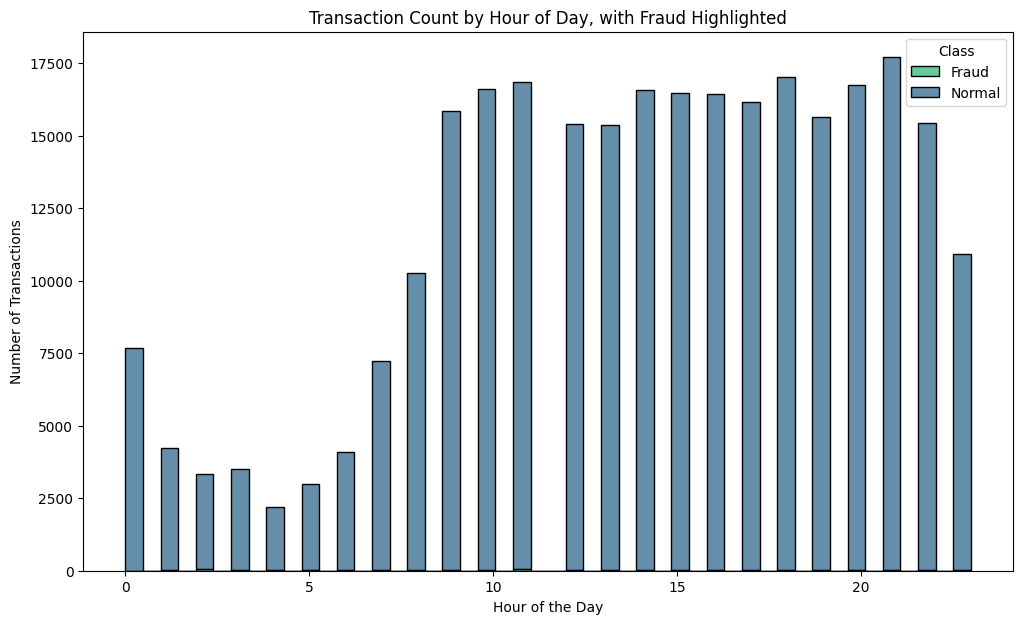

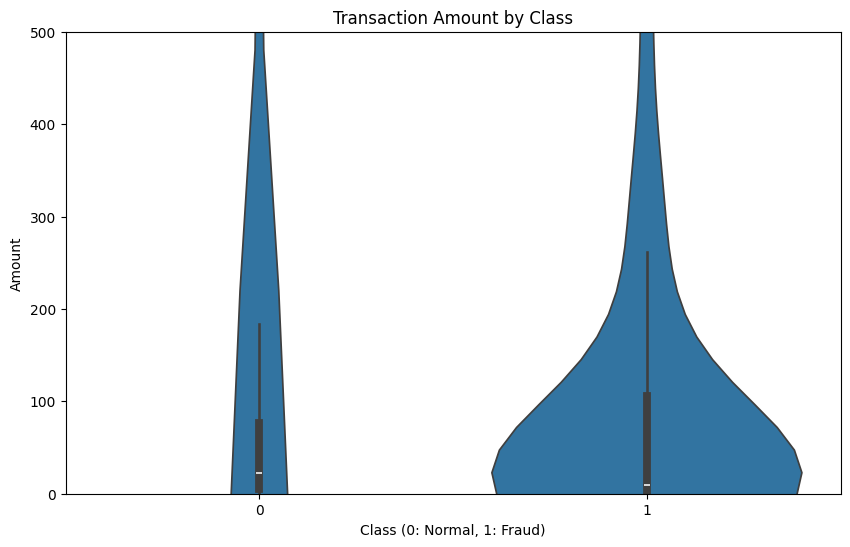

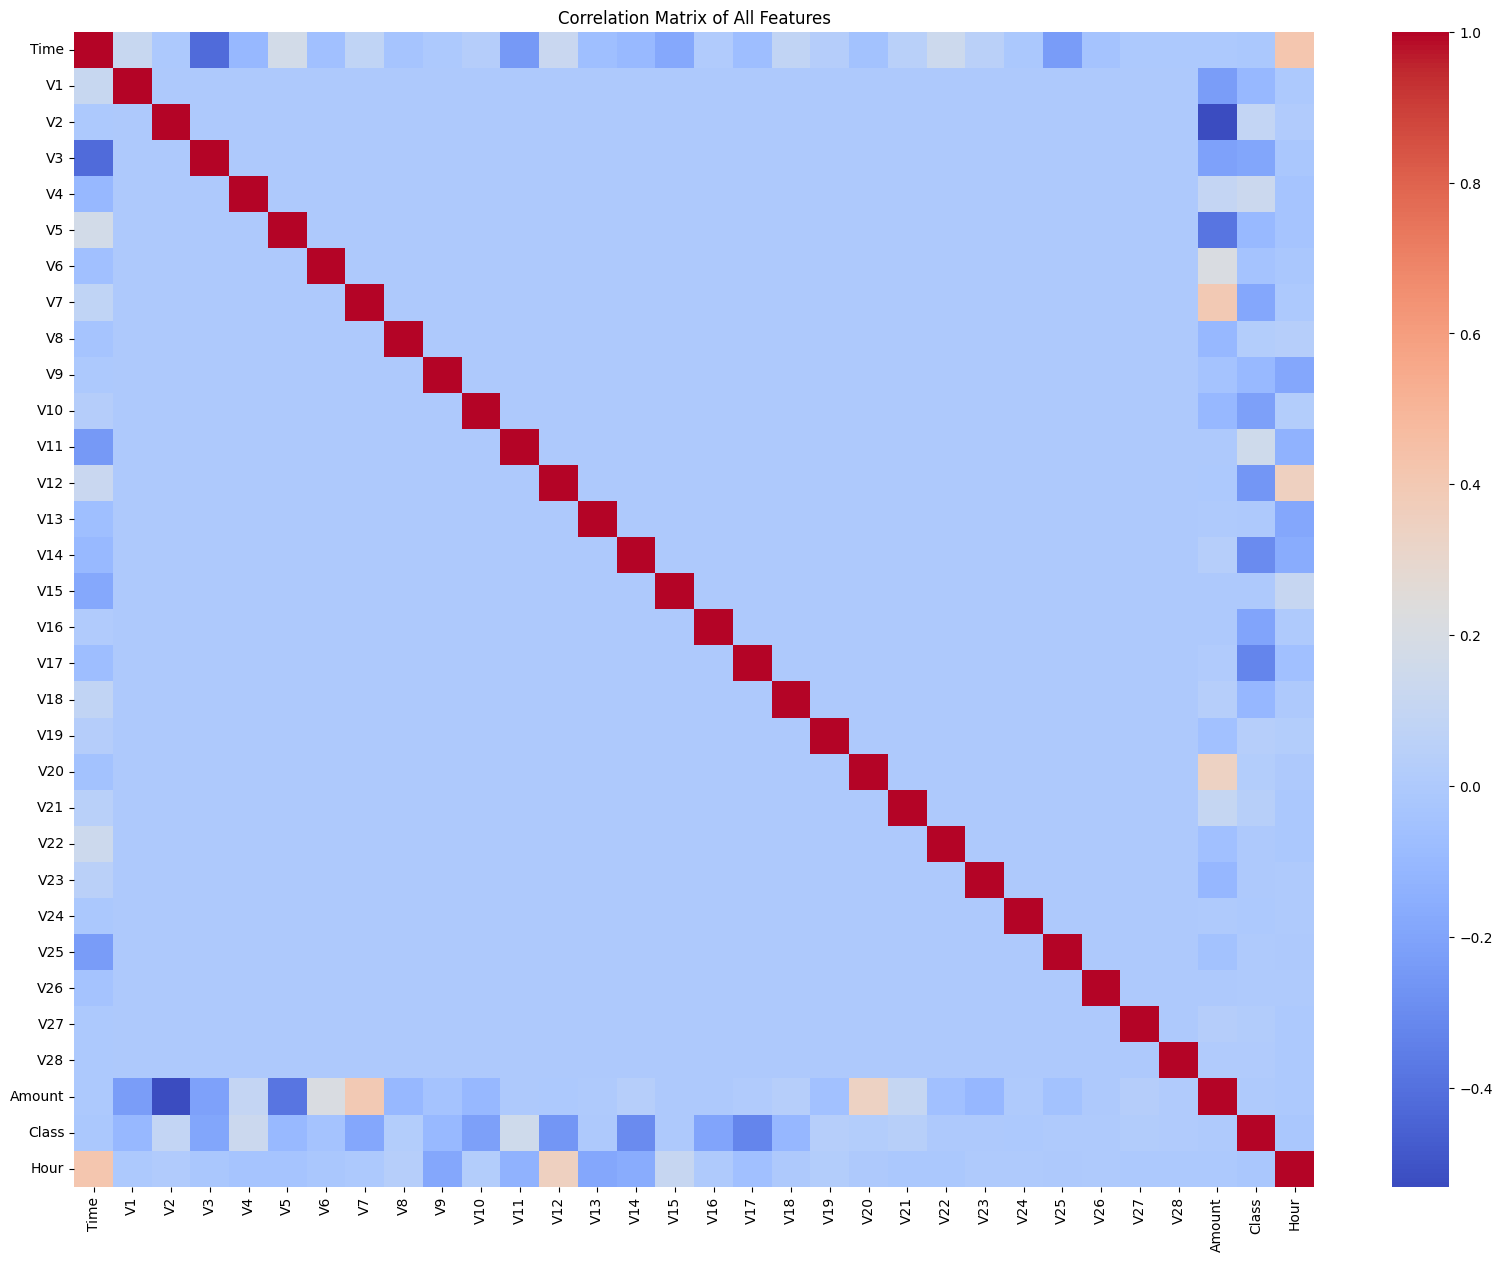

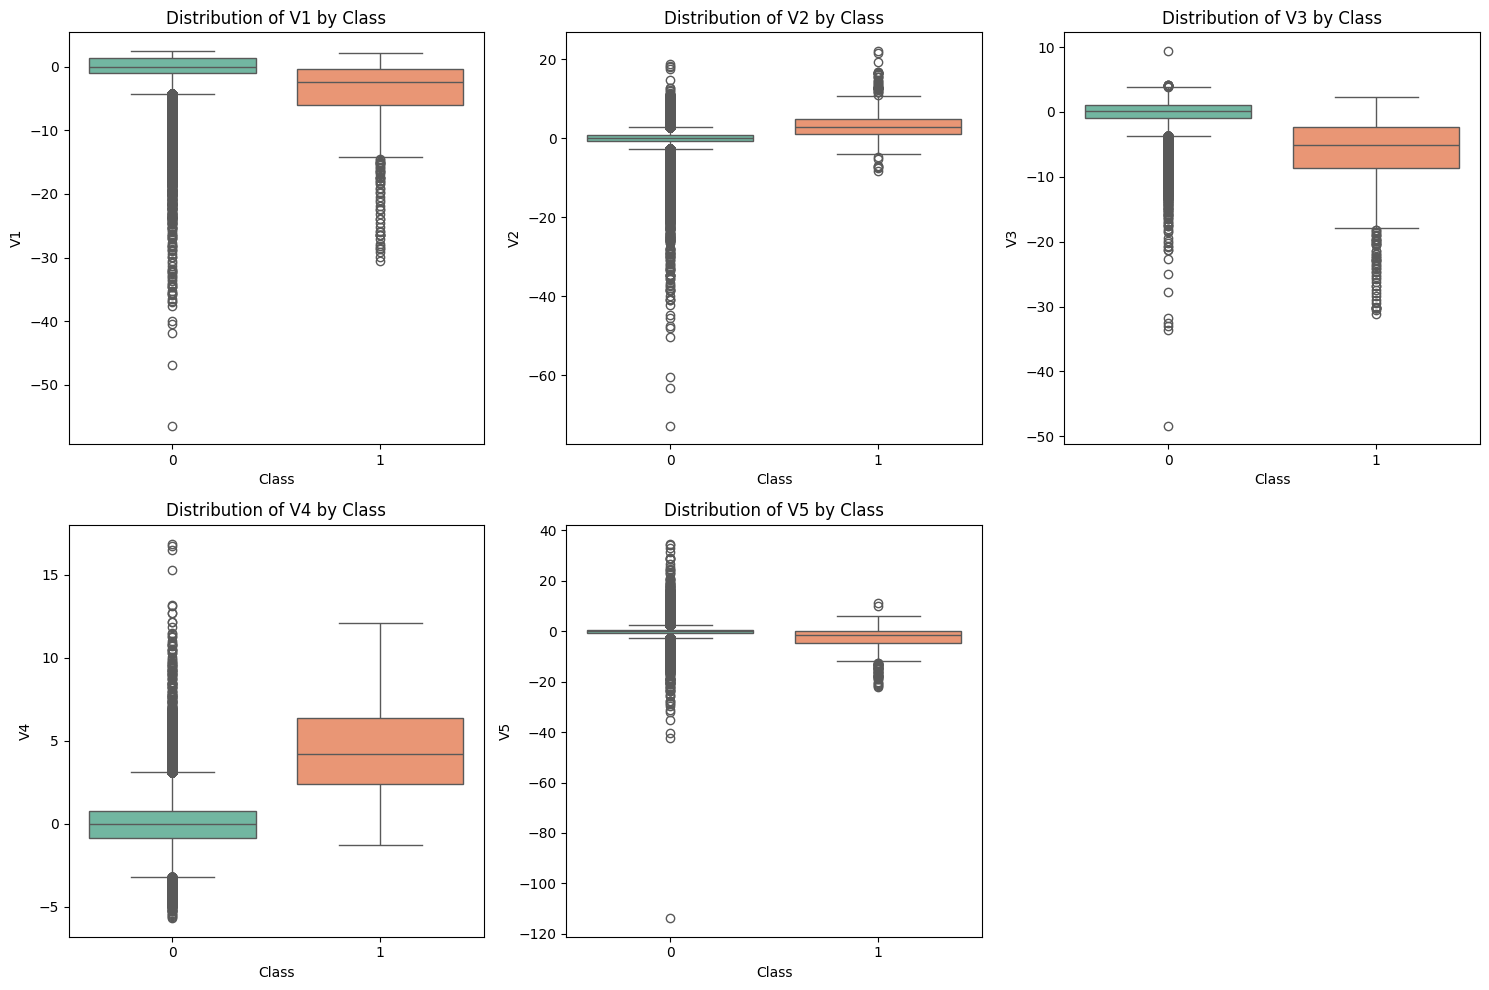

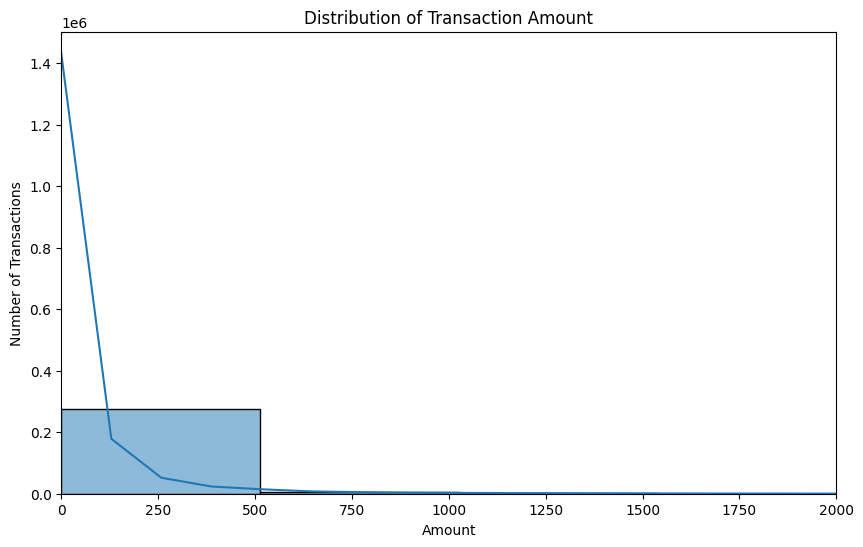

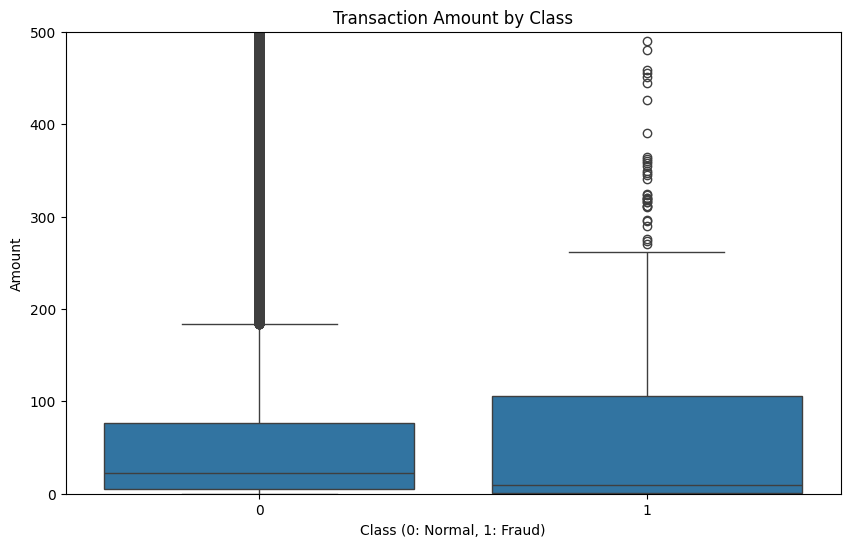


Engineered 'Hour' feature from 'Time' column on the entire dataframe.
First 5 rows of the dataframe with new feature:
   Time        V1        V2        V3        V4        V5        V6        V7  \
0   0.0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1   0.0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2   1.0 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3   1.0 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4   2.0 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   

         V8        V9  ...       V22       V23       V24       V25       V26  \
0  0.098698  0.363787  ...  0.277838 -0.110474  0.066928  0.128539 -0.189115   
1  0.085102 -0.255425  ... -0.638672  0.101288 -0.339846  0.167170  0.125895   
2  0.247676 -1.514654  ...  0.771679  0.909412 -0.689281 -0.327642 -0.139097   
3  0.377436 -1.387024  ...  0.005274 -0.190321 -1.175575  0.647376 -0.2219

In [ ]:
print("\n--- Enhanced Exploratory Data Analysis & Preprocessing ---")

# First, let's check for any missing values in the entire dataframe.
# This directly addresses the error you were seeing.
print("Checking for missing values:")
print(df.isnull().sum())
print("-" * 50)
if df.isnull().values.any():
    print("Missing values found. Dropping rows with NaNs.")
    df.dropna(inplace=True)
    print("Rows with NaNs have been dropped.")
else:
    print("No missing values found in the dataset.")
print("-" * 50)

# Visualize the class distribution (imbalance)
plt.figure(figsize=(8, 6))
sns.countplot(x='Class', data=df)
plt.title('Class Distribution: Normal (0) vs. Fraud (1)')
plt.xlabel('Class')
plt.ylabel('Number of Transactions')
plt.show()

# Visualize the distribution of fraudulent transactions by 'Hour'
# This helps identify if fraud is more common at certain times of the day
# First, let's create the 'Hour' feature from the 'Time' column for this visualization
df['Hour'] = df['Time'].apply(lambda x: np.floor(x / 3600) % 24)
plt.figure(figsize=(12, 7))
sns.histplot(data=df, x='Hour', hue='Class', bins=48, multiple='stack', palette='viridis')
plt.title('Transaction Count by Hour of Day, with Fraud Highlighted')
plt.xlabel('Hour of the Day')
plt.ylabel('Number of Transactions')
plt.legend(title='Class', labels=['Fraud', 'Normal'])
plt.show()


# Visualize the 'Amount' feature by class using a violin plot
# A violin plot combines a box plot with a kernel density estimate
plt.figure(figsize=(10, 6))
sns.violinplot(x='Class', y='Amount', data=df)
plt.title('Transaction Amount by Class')
plt.xlabel('Class (0: Normal, 1: Fraud)')
plt.ylabel('Amount')
plt.ylim(0, 500) # Limiting y-axis for better visualization
plt.show()

# Correlation Heatmap
# This helps us understand the relationships between the transformed features
plt.figure(figsize=(20, 15))
corr = df.corr()
sns.heatmap(corr, cmap='coolwarm', annot=False) # 'annot=False' for cleaner visualization
plt.title('Correlation Matrix of All Features')
plt.show()

# Box plots for selected PCA features by class
# This can show if certain features have different distributions for fraud vs. normal transactions
plt.figure(figsize=(15, 10))
features_to_plot = ['V1', 'V2', 'V3', 'V4', 'V5']
for i, feature in enumerate(features_to_plot):
    plt.subplot(2, 3, i + 1)
    sns.boxplot(x='Class', y=feature, data=df, palette='Set2')
    plt.title(f'Distribution of {feature} by Class')
plt.tight_layout()
plt.show()

# Visualize the distribution of the 'Amount' feature
plt.figure(figsize=(10, 6))
sns.histplot(df['Amount'], bins=50, kde=True)
plt.title('Distribution of Transaction Amount')
plt.xlabel('Amount')
plt.ylabel('Number of Transactions')
plt.xlim(0, 2000) # Limiting x-axis for better visualization due to outliers
plt.show()

# Visualize the 'Amount' feature by class using a box plot
plt.figure(figsize=(10, 6))
sns.boxplot(x='Class', y='Amount', data=df)
plt.title('Transaction Amount by Class')
plt.xlabel('Class (0: Normal, 1: Fraud)')
plt.ylabel('Amount')
plt.ylim(0, 500) # Limiting y-axis for better visualization
plt.show()

# --- Feature Engineering ---
# Create new features from 'Time' column on the entire dataframe
df['Hour'] = df['Time'].apply(lambda x: np.floor(x / 3600))
print("\nEngineered 'Hour' feature from 'Time' column on the entire dataframe.")
print("First 5 rows of the dataframe with new feature:")
print(df.head())


# --- Feature Scaling ---
# Scale 'Amount' feature on the entire dataframe using RobustScaler
# RobustScaler is less sensitive to outliers, which is ideal for this dataset.
scaler = RobustScaler()
df['Amount'] = scaler.fit_transform(df[['Amount']])
print("\n'Amount' feature scaled using RobustScaler on the entire dataframe.")
print("First 5 rows of the dataframe after scaling:")
print(df.head())

In [ ]:
# --- Feature Engineering ---
# Create new features from 'Time' column on the entire dataframe
df['Hour'] = df['Time'].apply(lambda x: np.floor(x / 3600))
print("\nEngineered 'Hour' feature from 'Time' column on the entire dataframe.")
print("First 5 rows of the dataframe with new feature:")
print(df.head())

# Drop the original 'Time' column as 'Hour' is more interpretable
df = df.drop('Time', axis=1)

# --- Feature Scaling ---
# Scale 'Amount' feature on the entire dataframe using RobustScaler
# RobustScaler is less sensitive to outliers, which is ideal for this dataset.
scaler = RobustScaler()
df['Amount'] = scaler.fit_transform(df[['Amount']])
print("\n'Amount' feature scaled using RobustScaler on the entire dataframe.")
print("First 5 rows of the dataframe after scaling:")
print(df.head())


Engineered 'Hour' feature from 'Time' column on the entire dataframe.
First 5 rows of the dataframe with new feature:
   Time        V1        V2        V3        V4        V5        V6        V7  \
0   0.0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1   0.0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2   1.0 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3   1.0 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4   2.0 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   

         V8        V9  ...       V22       V23       V24       V25       V26  \
0  0.098698  0.363787  ...  0.277838 -0.110474  0.066928  0.128539 -0.189115   
1  0.085102 -0.255425  ... -0.638672  0.101288 -0.339846  0.167170  0.125895   
2  0.247676 -1.514654  ...  0.771679  0.909412 -0.689281 -0.327642 -0.139097   
3  0.377436 -1.387024  ...  0.005274 -0.190321 -1.175575  0.647376 -0.2219

In [ ]:
# Separate features and target variable
X = df.drop('Class', axis=1)
y = df['Class']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)


In [ ]:
# --- Handle Class Imbalance with SMOTE ---
print("\n--- Handling Class Imbalance with SMOTE ---")
print("Original training data class distribution:")
print(y_train.value_counts())

smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

print("\nResampled training data class distribution:")
print(pd.Series(y_train_resampled).value_counts())



--- Handling Class Imbalance with SMOTE ---
Original training data class distribution:
Class
0    227451
1       394
Name: count, dtype: int64

Resampled training data class distribution:
Class
0    227451
1    227451
Name: count, dtype: int64


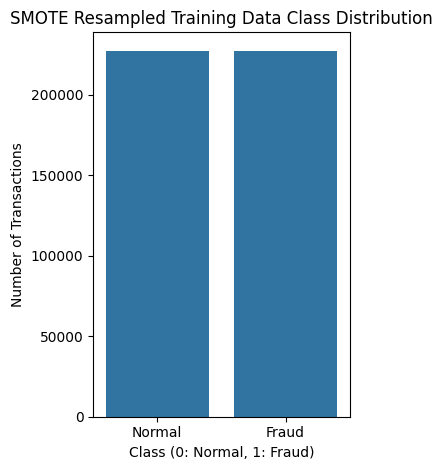

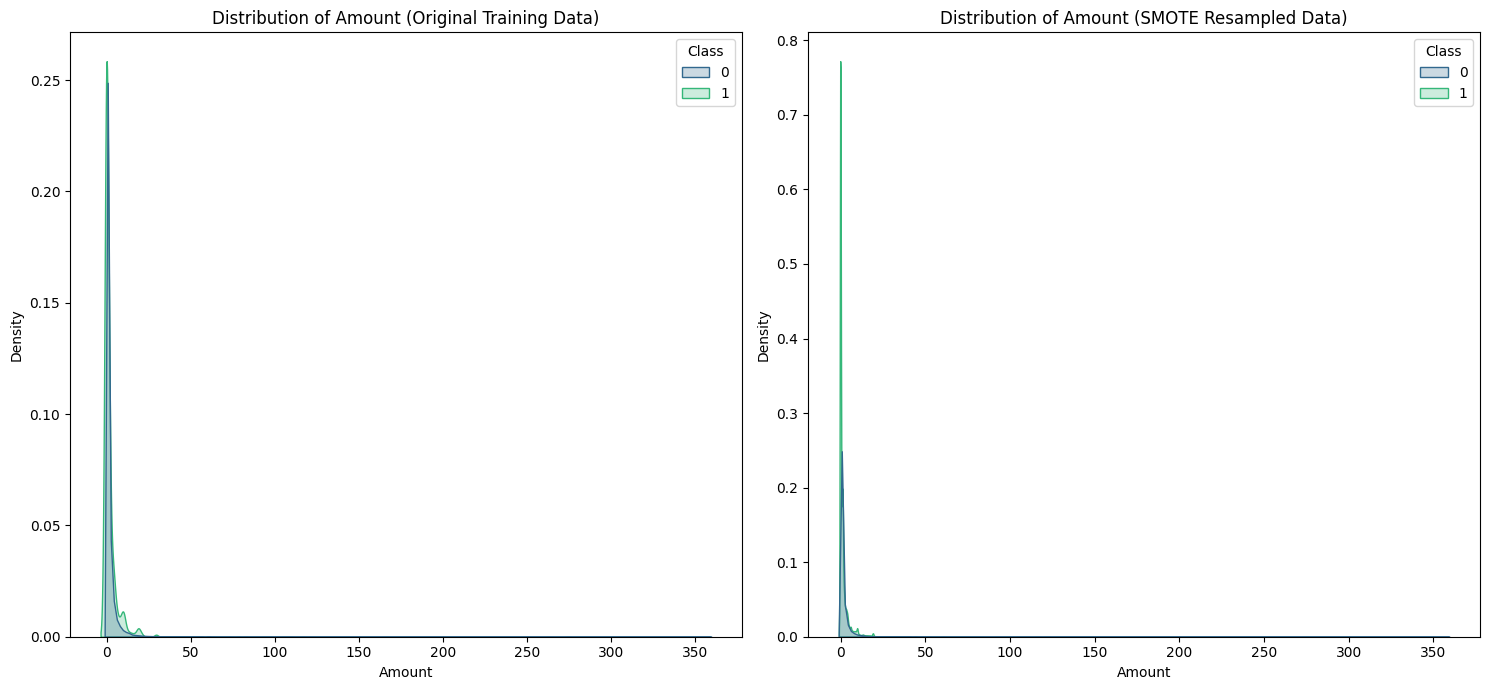

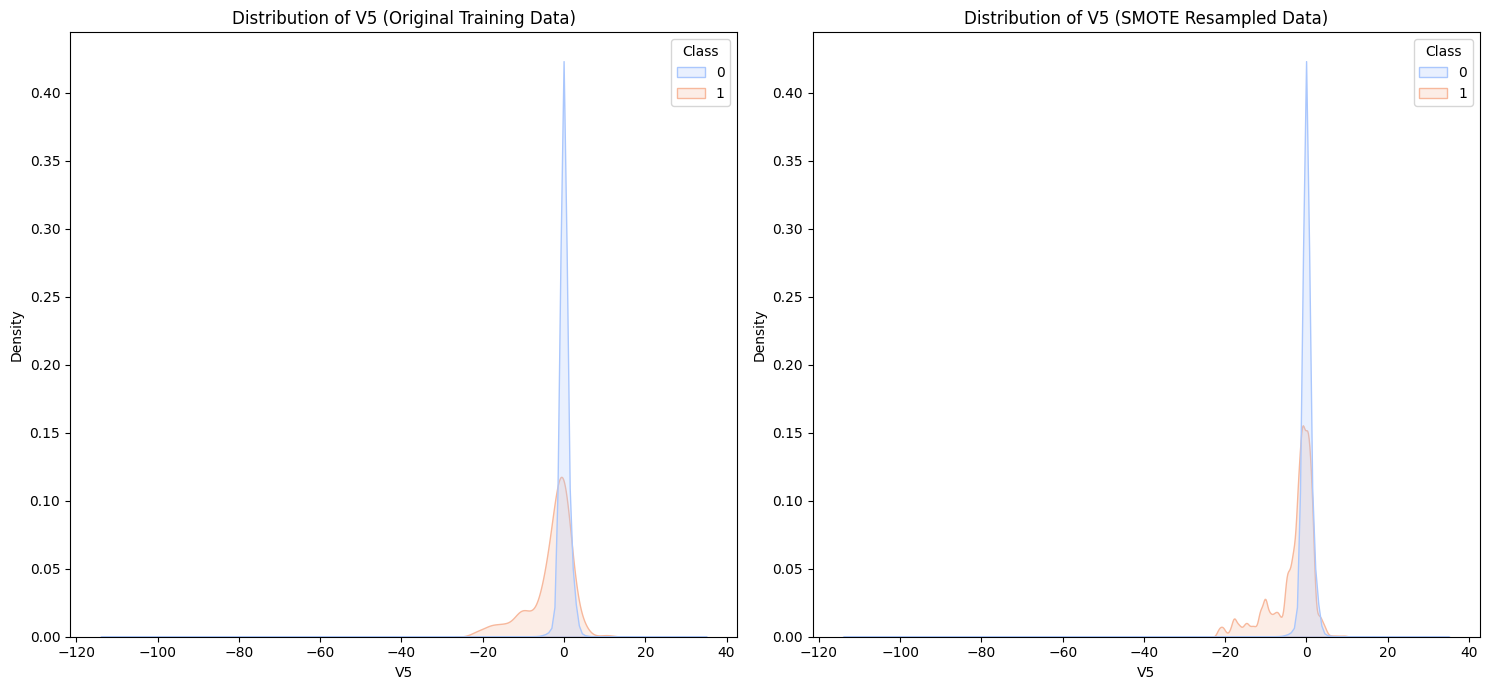

In [ ]:
# 2. Visualize the class distribution of the resampled training data
plt.subplot(1, 2, 2)
sns.countplot(x=y_train_resampled)
plt.title('SMOTE Resampled Training Data Class Distribution')
plt.xlabel('Class (0: Normal, 1: Fraud)')
plt.ylabel('Number of Transactions')
plt.xticks([0, 1], ['Normal', 'Fraud'])
plt.tight_layout()
plt.show()

# 3. Visualize the distribution of 'Amount' before and after SMOTE
# We use KDE plots to see the density of data points
plt.figure(figsize=(15, 7))
plt.subplot(1, 2, 1)
sns.kdeplot(data=X_train, x='Amount', hue=y_train, fill=True, common_norm=False, palette='viridis')
plt.title('Distribution of Amount (Original Training Data)')

plt.subplot(1, 2, 2)
sns.kdeplot(data=X_train_resampled, x='Amount', hue=y_train_resampled, fill=True, common_norm=False, palette='viridis')
plt.title('Distribution of Amount (SMOTE Resampled Data)')
plt.tight_layout()
plt.show()

# 4. Visualize the distribution of a PCA feature (e.g., 'V1') before and after SMOTE
plt.figure(figsize=(15, 7))
plt.subplot(1, 2, 1)
sns.kdeplot(data=X_train, x='V5', hue=y_train, fill=True, common_norm=False, palette='coolwarm')
plt.title('Distribution of V5 (Original Training Data)')

plt.subplot(1, 2, 2)
sns.kdeplot(data=X_train_resampled, x='V5', hue=y_train_resampled, fill=True, common_norm=False, palette='coolwarm')
plt.title('Distribution of V5 (SMOTE Resampled Data)')
plt.tight_layout()
plt.show()

In [ ]:

# # --- Phase 2: Exploratory Data Analysis (EDA) and Preprocessing with Visualizations ---

# print("\n--- Enhanced Exploratory Data Analysis & Preprocessing ---")

# # Visualize the distribution of the 'Time' feature
# plt.figure(figsize=(10, 6))
# sns.histplot(df['Time'], bins=50, kde=True)
# plt.title('Distribution of Transaction Time')
# plt.xlabel('Time (seconds from first transaction)')
# plt.ylabel('Number of Transactions')
# plt.show()

# # Visualize the distribution of the 'Amount' feature
# plt.figure(figsize=(10, 6))
# sns.histplot(df['Amount'], bins=50, kde=True)
# plt.title('Distribution of Transaction Amount')
# plt.xlabel('Amount')
# plt.ylabel('Number of Transactions')
# plt.xlim(0, 2000) # Limiting x-axis for better visualization due to outliers
# plt.show()

# # Visualize the 'Amount' feature by class using a box plot
# plt.figure(figsize=(10, 6))
# sns.boxplot(x='Class', y='Amount', data=df)
# plt.title('Transaction Amount by Class')
# plt.xlabel('Class (0: Normal, 1: Fraud)')
# plt.ylabel('Amount')
# plt.ylim(0, 500) # Limiting y-axis for better visualization
# plt.show()



--- Enhanced Exploratory Data Analysis & Preprocessing ---


KeyError: 'Time'

<Figure size 1000x600 with 0 Axes>

In [ ]:
# --- Phase 3: Model Development & Training ---
print("\n--- Training and Evaluating Multiple Models ---")

# Define the models to be trained
models = {
    'Logistic Regression': LogisticRegression(random_state=42, solver='liblinear'),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'XGBoost': XGBClassifier(objective='binary:logistic', n_estimators=100, learning_rate=0.1, random_state=42, use_label_encoder=False, eval_metric='logloss'),
    'LightGBM': LGBMClassifier(n_estimators=100, learning_rate=0.1, random_state=42)
}

results = []

for model_name, model in models.items():
    print(f"\nTraining {model_name}...")
    model.fit(X_train_resampled, y_train_resampled)
    print(f"Training for {model_name} complete.")

    # Make predictions on the original, unseen test data
    y_pred = model.predict(X_test)
    y_pred_proba = model.predict_proba(X_test)[:, 1]

    # Evaluate the model
    print(f"\nEvaluation for {model_name}:")
    print(classification_report(y_test, y_pred))

    # Calculate and store performance metrics
    auc_roc = roc_auc_score(y_test, y_pred_proba)
    # The accuracy is calculated on the original test set, not the resampled data
    train_accuracy = accuracy_score(y_train, model.predict(X_train))
    test_accuracy = accuracy_score(y_test, y_pred)

    results.append({
        'Model': model_name,
        'AUC-ROC Score': auc_roc,
        'Training Accuracy': train_accuracy,
        'Test Accuracy': test_accuracy
    })
    print(f"AUC-ROC Score: {auc_roc:.4f}, Test Accuracy: {test_accuracy:.4f}")


--- Training and Evaluating Multiple Models ---

Training Logistic Regression...
Training for Logistic Regression complete.

Evaluation for Logistic Regression:
              precision    recall  f1-score   support

           0       1.00      0.97      0.99     56864
           1       0.06      0.92      0.11        98

    accuracy                           0.97     56962
   macro avg       0.53      0.95      0.55     56962
weighted avg       1.00      0.97      0.99     56962

AUC-ROC Score: 0.9708, Test Accuracy: 0.9739

Training Decision Tree...
Training for Decision Tree complete.

Evaluation for Decision Tree:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.34      0.76      0.47        98

    accuracy                           1.00     56962
   macro avg       0.67      0.88      0.73     56962
weighted avg       1.00      1.00      1.00     56962

AUC-ROC Score: 0.8763, Test Accuracy: 0.9970


--- Final Model Comparison ---
                 Model  AUC-ROC Score  Training Accuracy  Test Accuracy
3              XGBoost       0.978303           0.997639       0.996700
0  Logistic Regression       0.970806           0.974452       0.973877
2        Random Forest       0.963587           1.000000       0.999473
4             LightGBM       0.927519           0.999039       0.998280
1        Decision Tree       0.876276           1.000000       0.997033


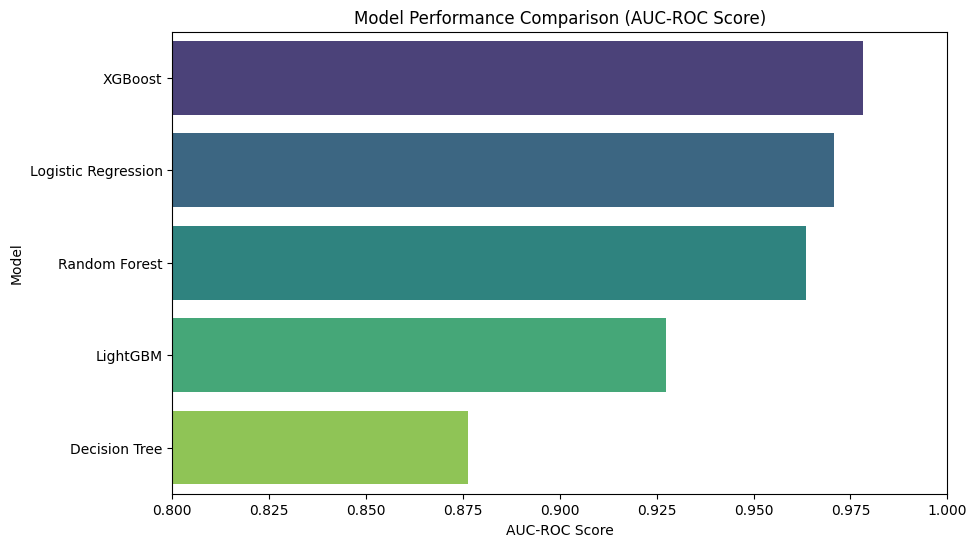

In [ ]:
# --- Phase 4: Model Comparison ---
print("\n--- Final Model Comparison ---")
results_df = pd.DataFrame(results).sort_values(by='AUC-ROC Score', ascending=False)
print(results_df)

# Visualize the comparison
plt.figure(figsize=(10, 6))
sns.barplot(x='AUC-ROC Score', y='Model', data=results_df, palette='viridis')
plt.title('Model Performance Comparison (AUC-ROC Score)')
plt.xlabel('AUC-ROC Score')
plt.ylabel('Model')
plt.xlim(0.8, 1.0) # Focus on the higher performance range
plt.show()

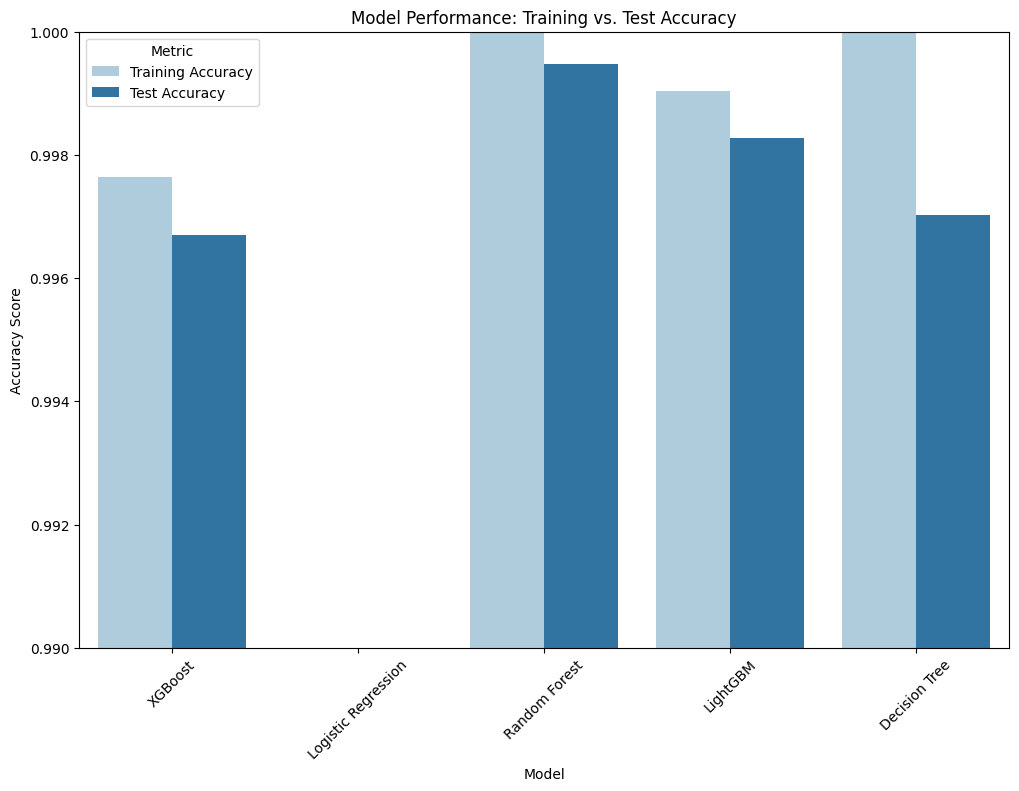

In [ ]:
# Visualize Training vs. Test Accuracy
results_long = pd.melt(results_df, id_vars='Model', value_vars=['Training Accuracy', 'Test Accuracy'], var_name='Metric', value_name='Score')
plt.figure(figsize=(12, 8))
sns.barplot(x='Model', y='Score', hue='Metric', data=results_long, palette='Paired')
plt.title('Model Performance: Training vs. Test Accuracy')
plt.xlabel('Model')
plt.ylabel('Accuracy Score')
plt.ylim(0.99, 1.0) # Focus on the relevant accuracy range
plt.xticks(rotation=45)
plt.show()